# **BASELINE ORIGINAL RESULTS**

In [ ]:
n_pos, n_neg = y.sum(), len(y) - y.sum()
scale_pos_weight = n_neg / n_pos

params = {
    "objective": "binary", "metric": "auc", "verbosity": -1,
    "seed": 42, "scale_pos_weight": scale_pos_weight,
}

# K-Fold Cross Validation: 5 folds.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    ds_tr = lgb.Dataset(X.iloc[tr_idx], label=y.iloc[tr_idx], categorical_feature=CATEGORICAL_COLS)
    ds_va = lgb.Dataset(X.iloc[va_idx], label=y.iloc[va_idx], categorical_feature=CATEGORICAL_COLS, reference=ds_tr)
    m = lgb.train(params, ds_tr, num_boost_round=500, valid_sets=[ds_va],
                  callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
    auc = roc_auc_score(y.iloc[va_idx], m.predict(X.iloc[va_idx], num_iteration=m.best_iteration))
    cv_aucs.append(auc)
    print(f"Fold {fold}: AUC = {auc:.4f}")

print(f"New CV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")

#Baseline Preformance AUC: 0.8601

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[249]	valid_0's auc: 0.860403
Fold 1: AUC = 0.8604
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[193]	valid_0's auc: 0.852493
Fold 2: AUC = 0.8525
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[129]	valid_0's auc: 0.864467
Fold 3: AUC = 0.8645
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[139]	valid_0's auc: 0.861433
Fold 4: AUC = 0.8614
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[163]	valid_0's auc: 0.861567
Fold 5: AUC = 0.8616
New CV AUC: 0.8601 ± 0.0040
Previous baseline was: 0.8601 ± 0.0040 — compare against that


#  **1) LOAD DATA**
--------------------------------------------------------------------------------------

In [24]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, classification_report
import joblib

DATA_PATH = "train_data 2.csv"
TARGET_COL = "Opportunity Result"

CATEGORICAL_COLS = ["Route To Market", "Supplies Subgroup", "Competitor Type"]
NUMERIC_COLS = [
    "Elapsed Days In Sales Stage", "Sales Stage Change Count",
    "Client Size By Revenue", "Revenue From Client Past Two Years",
    "Is Stalled", "Bounced A Lot", "Is Existing Client",
    "High Risk Deal", "Stage Bounce Rate",
]

df = pd.read_csv(DATA_PATH)

# **2) ADDING NEW FEATURES**
--------------------------------------------------------------------------------------

### Update: Did not improve preformance, so I got rid of these ultimately

In [ ]:
# 1. BOTH stalled AND unstable
#df["Stall_Bounce_Interaction"] = df["Elapsed Days In Sales Stage"] * df["Sales Stage Change Count"]

# 2. Log-transform skewed numeric columns.
#    Revenues are usually right-skewed

#df["Log_Client_Size"] = np.log1p(df["Client Size By Revenue"])
#df["Log_Revenue_Past_2Y"] = np.log1p(df["Revenue From Client Past Two Years"])

In [15]:
#NUMERIC_COLS = NUMERIC_COLS + ["Stall_Bounce_Interaction", "Log_Client_Size", "Log_Revenue_Past_2Y"]
FEATURES = CATEGORICAL_COLS + NUMERIC_COLS

for col in CATEGORICAL_COLS:
    df[col] = df[col].astype("category")

y = df[TARGET_COL].astype(int)
X = df[FEATURES]

In [12]:
print(df)

       Opportunity Number  Opportunity Result  Opportunity Amount USD  \
0                 9489573                   0                  300000   
1                 7910456                   0                   33400   
2                 7791278                   0                   20000   
3                 6518541                   0                     600   
4                 7713087                   1                   80000   
...                   ...                 ...                     ...   
62371             6848208                   0                   10000   
62372             8072406                   0                       0   
62373             8372051                   0                   93008   
62374             7713012                   0                   12000   
62375             6792533                   0                   70000   

       Elapsed Days In Sales Stage  Sales Stage Change Count  \
0                                4                         

# **3) Train Model**
--------------------------------------------------------------------------------------

In [ ]:
n_pos, n_neg = y.sum(), len(y) - y.sum()
scale_pos_weight = n_neg / n_pos

#Binary problem
#AUC b/c we have a heavy class imbalance and we don't want our model to start to learn to pick "no" simply because there is more data for no
#scale pos weight b/c we have way more no's than yes's in our dataset 
params = {
    "objective": "binary", "metric": "auc", "verbosity": -1,
    "seed": 42, "scale_pos_weight": scale_pos_weight,
}

# K-Fold Cross Validation: 5 folds.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    ds_tr = lgb.Dataset(X.iloc[tr_idx], label=y.iloc[tr_idx], categorical_feature=CATEGORICAL_COLS)
    ds_va = lgb.Dataset(X.iloc[va_idx], label=y.iloc[va_idx], categorical_feature=CATEGORICAL_COLS, reference=ds_tr)
    m = lgb.train(params, ds_tr, num_boost_round=500, valid_sets=[ds_va],
                  callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
    auc = roc_auc_score(y.iloc[va_idx], m.predict(X.iloc[va_idx], num_iteration=m.best_iteration))
    cv_aucs.append(auc)
    print(f"Fold {fold}: AUC = {auc:.4f}")

print(f"New CV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
print(f"Previous baseline was: 0.8601 ± 0.0040 — compare against that")

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[161]	valid_0's auc: 0.858469
Fold 1: AUC = 0.8585
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[153]	valid_0's auc: 0.852836
Fold 2: AUC = 0.8528
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[214]	valid_0's auc: 0.864615
Fold 3: AUC = 0.8646
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[119]	valid_0's auc: 0.860058
Fold 4: AUC = 0.8601
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[150]	valid_0's auc: 0.86052
Fold 5: AUC = 0.8605
New CV AUC: 0.8593 ± 0.0038
Previous baseline was: 0.8601 ± 0.0040 — compare against that


### **Added Features did not help...**

# **4) Tuning Percentage Threshold**
--------------------------------------------------------------------------------------

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
ds_train = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_COLS)
ds_test = lgb.Dataset(X_test, label=y_test, categorical_feature=CATEGORICAL_COLS, reference=ds_train)

final_model = lgb.train(params, ds_train, num_boost_round=500, valid_sets=[ds_test],
                        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])

y_prob = final_model.predict(X_test, num_iteration=final_model.best_iteration)


# See what threshold gives the highest F1 & pick
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Default threshold (0.5) F1: {f1_score(y_test, (y_prob >= 0.5).astype(int)):.4f}")
print(f"Best threshold ({best_threshold:.3f}) F1: {f1_scores[best_idx]:.4f}")

print("\n--- At default 0.5 threshold ---")
print(classification_report(y_test, (y_prob >= 0.5).astype(int), target_names=["Loss", "Win"]))
print(f"\n--- At tuned threshold ({best_threshold:.3f}) ---")
print(classification_report(y_test, (y_prob >= best_threshold).astype(int), target_names=["Loss", "Win"]))

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[139]	valid_0's auc: 0.860884
Default threshold (0.5) F1: 0.6162
Best threshold (0.612) F1: 0.6411

--- At default 0.5 threshold ---
              precision    recall  f1-score   support

        Loss       0.91      0.82      0.86      9660
         Win       0.53      0.73      0.62      2816

    accuracy                           0.80     12476
   macro avg       0.72      0.77      0.74     12476
weighted avg       0.83      0.80      0.81     12476


--- At tuned threshold (0.612) ---
              precision    recall  f1-score   support

        Loss       0.89      0.90      0.90      9660
         Win       0.66      0.63      0.64      2816

    accuracy                           0.84     12476
   macro avg       0.77      0.77      0.77     12476
weighted avg       0.84      0.84      0.84     12476



### **Tuning threshold impacted F1 Score by 0.04**

# **TRYING WITH OPPORTUNITY AMOUNT** 

In [50]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, classification_report
import joblib

DATA_PATH = "train_data 2.csv"
TARGET_COL = "Opportunity Result"

CATEGORICAL_COLS = ["Route To Market", "Supplies Subgroup", "Competitor Type"]
NUMERIC_COLS = [
    "Elapsed Days In Sales Stage", "Sales Stage Change Count",
    "Client Size By Revenue", "Revenue From Client Past Two Years",
    "Is Stalled", "Bounced A Lot", "Is Existing Client",
    "High Risk Deal", "Stage Bounce Rate",
]

df = pd.read_csv(DATA_PATH)

In [51]:
NUMERIC_COLS = NUMERIC_COLS + ["Opportunity Amount USD"]
FEATURES = CATEGORICAL_COLS + NUMERIC_COLS

for col in CATEGORICAL_COLS:
    df[col] = df[col].astype("category")

y = df[TARGET_COL].astype(int)
X = df[FEATURES]

In [41]:
print(NUMERIC_COLS)

['Elapsed Days In Sales Stage', 'Sales Stage Change Count', 'Client Size By Revenue', 'Revenue From Client Past Two Years', 'Is Stalled', 'Bounced A Lot', 'Is Existing Client', 'High Risk Deal', 'Stage Bounce Rate', 'Opportunity Amount USD', 'Opportunity Amount USD', 'Opportunity Amount USD']


In [40]:
print(df)

       Opportunity Number  Opportunity Result  Opportunity Amount USD  \
0                 9489573                   0                  300000   
1                 7910456                   0                   33400   
2                 7791278                   0                   20000   
3                 6518541                   0                     600   
4                 7713087                   1                   80000   
...                   ...                 ...                     ...   
62371             6848208                   0                   10000   
62372             8072406                   0                       0   
62373             8372051                   0                   93008   
62374             7713012                   0                   12000   
62375             6792533                   0                   70000   

       Elapsed Days In Sales Stage  Sales Stage Change Count  \
0                                4                         

In [52]:
print(X.columns.tolist())

['Route To Market', 'Supplies Subgroup', 'Competitor Type', 'Elapsed Days In Sales Stage', 'Sales Stage Change Count', 'Client Size By Revenue', 'Revenue From Client Past Two Years', 'Is Stalled', 'Bounced A Lot', 'Is Existing Client', 'High Risk Deal', 'Stage Bounce Rate', 'Opportunity Amount USD']


In [ ]:
n_pos, n_neg = y.sum(), len(y) - y.sum()
scale_pos_weight = n_neg / n_pos

params = {
    "objective": "binary", "metric": "auc", "verbosity": -1,
    "seed": 42, "scale_pos_weight": scale_pos_weight,
}

# K-Fold Cross Validation: 5 folds.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    ds_tr = lgb.Dataset(X.iloc[tr_idx], label=y.iloc[tr_idx], categorical_feature=CATEGORICAL_COLS)
    ds_va = lgb.Dataset(X.iloc[va_idx], label=y.iloc[va_idx], categorical_feature=CATEGORICAL_COLS, reference=ds_tr)
    m = lgb.train(params, ds_tr, num_boost_round=500, valid_sets=[ds_va],
                  callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
    auc = roc_auc_score(y.iloc[va_idx], m.predict(X.iloc[va_idx], num_iteration=m.best_iteration))
    cv_aucs.append(auc)
    print(f"Fold {fold}: AUC = {auc:.4f}")

print(f"New CV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
print(f"Previous baseline was: 0.8601 ± 0.0040")

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[241]	valid_0's auc: 0.903402
Fold 1: AUC = 0.9034
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[259]	valid_0's auc: 0.897754
Fold 2: AUC = 0.8978
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[279]	valid_0's auc: 0.907146
Fold 3: AUC = 0.9071
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[216]	valid_0's auc: 0.900946
Fold 4: AUC = 0.9009
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[280]	valid_0's auc: 0.906095
Fold 5: AUC = 0.9061
New CV AUC: 0.9031 ± 0.0034
Previous baseline was: 0.8601 ± 0.0040 — compare against that


### **Preformance jumped massively, I am going to double check there is no leakages**

### Update: Correlation is -0.074, should be fine

In [54]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

ds_train = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_COLS)
ds_val = lgb.Dataset(X_val, label=y_val, categorical_feature=CATEGORICAL_COLS, reference=ds_train)

final_model = lgb.train(params, ds_train, num_boost_round=500, valid_sets=[ds_val],
                        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])

y_val_prob = final_model.predict(X_val, num_iteration=final_model.best_iteration)
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Threshold chosen on validation: {best_threshold:.3f}")
print(f"Validation F1 at this threshold: {f1_scores[best_idx]:.4f}")

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[266]	valid_0's auc: 0.905666
Threshold chosen on validation: 0.597
Validation F1 at this threshold: 0.6983


# **6) COLLECT METRICS ON FULLY UNSEEN DATA**
--------------------------------------------------------------------------------------

In [55]:
df_test = pd.read_csv("test_data 2.csv")
for col in CATEGORICAL_COLS:
    df_test[col] = df_test[col].astype("category")

X_test = df_test[FEATURES]
y_test = df_test[TARGET_COL].astype(int)

y_test_prob = final_model.predict(X_test, num_iteration=final_model.best_iteration)
test_auc = roc_auc_score(y_test, y_test_prob)

print(f"Test AUC: {test_auc:.4f}")
print(classification_report(y_test, (y_test_prob >= best_threshold).astype(int), target_names=["Loss", "Win"]))

joblib.dump(final_model, "win_probability_model_final.pkl")
joblib.dump({"best_threshold": best_threshold, "features": FEATURES}, "model_config.pkl")

Test AUC: 0.9053
              precision    recall  f1-score   support

        Loss       0.92      0.89      0.90     12074
         Win       0.66      0.73      0.69      3520

    accuracy                           0.85     15594
   macro avg       0.79      0.81      0.80     15594
weighted avg       0.86      0.85      0.86     15594



['model_config.pkl']

# **7) Generate Plots to visualize our data**

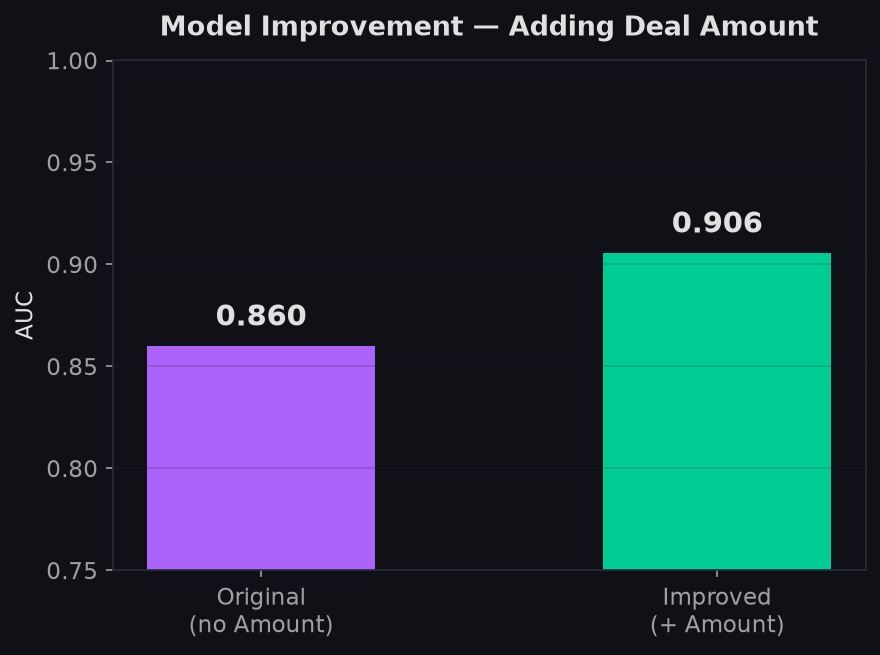

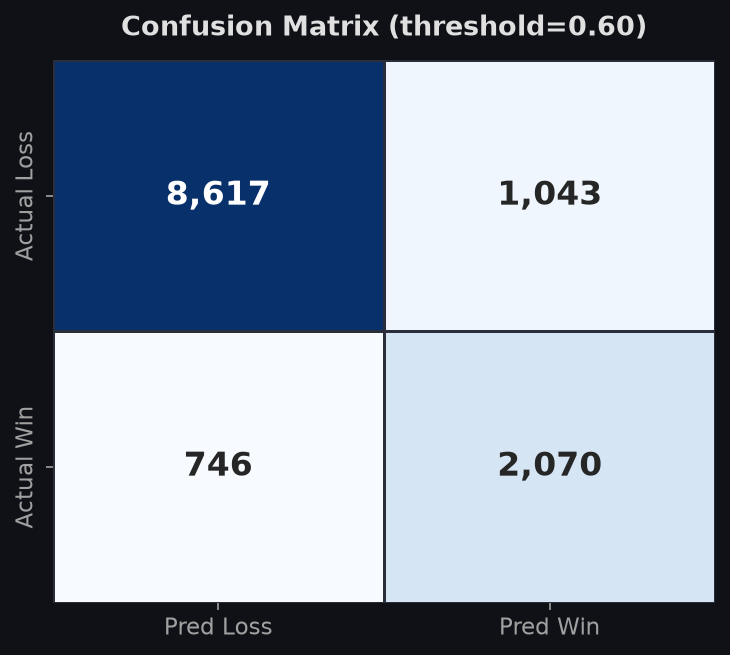

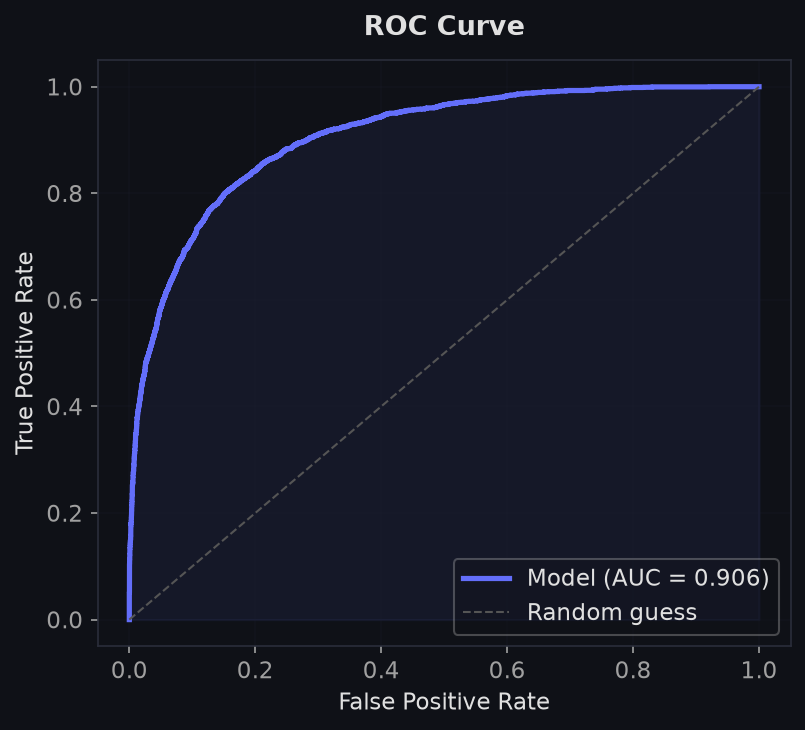

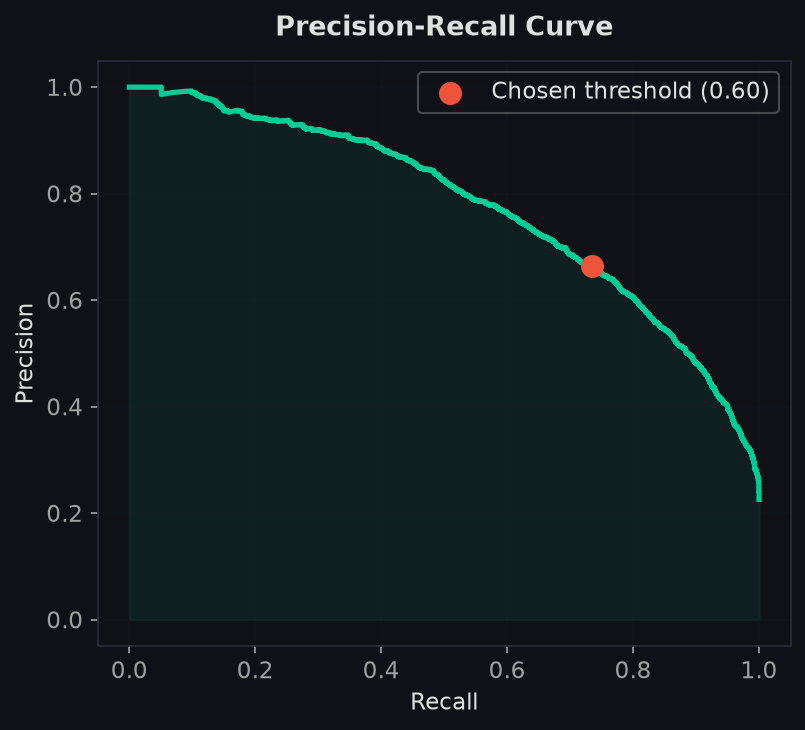

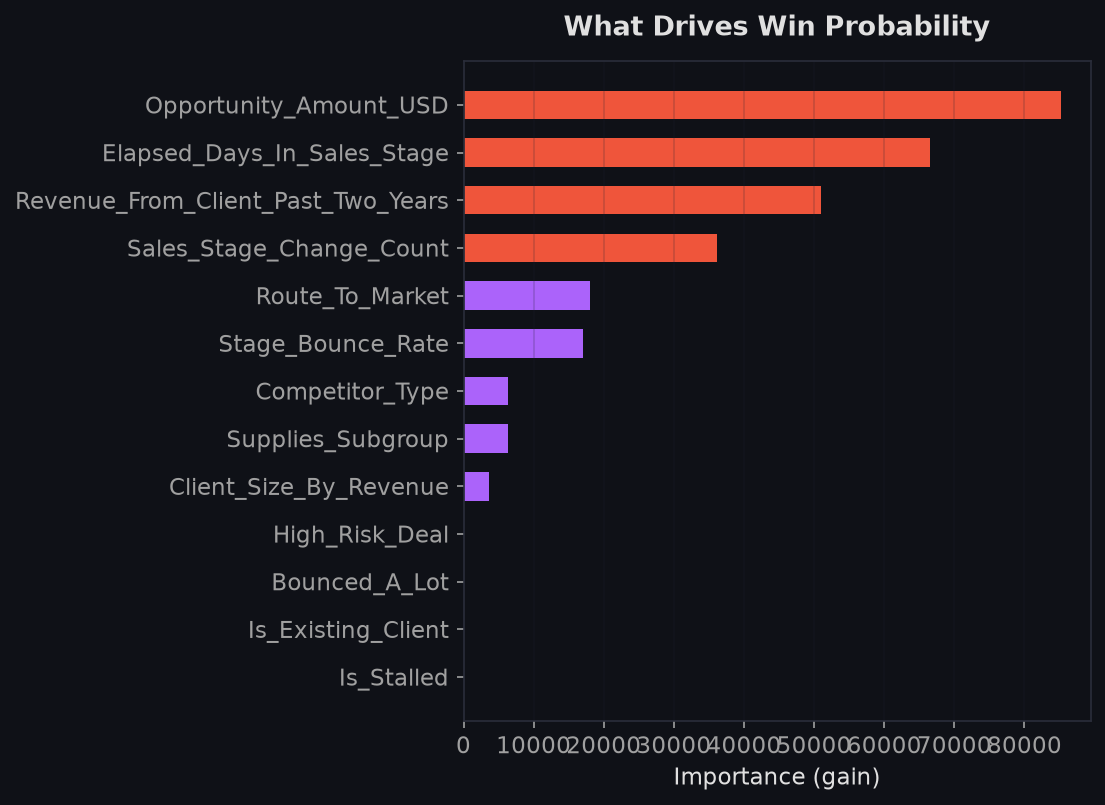

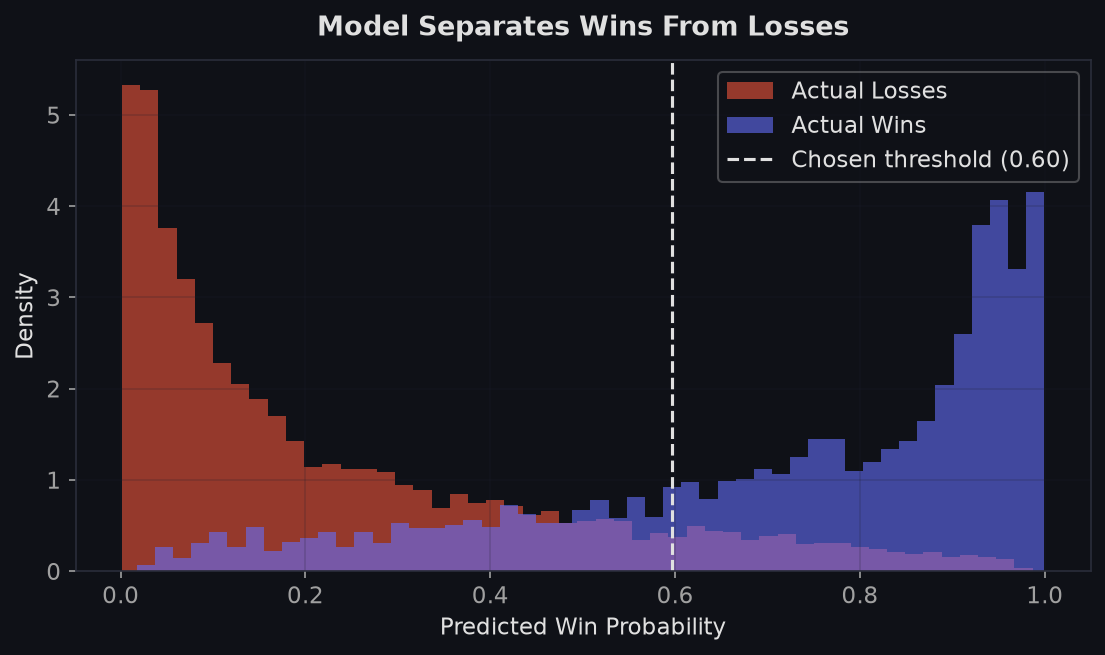

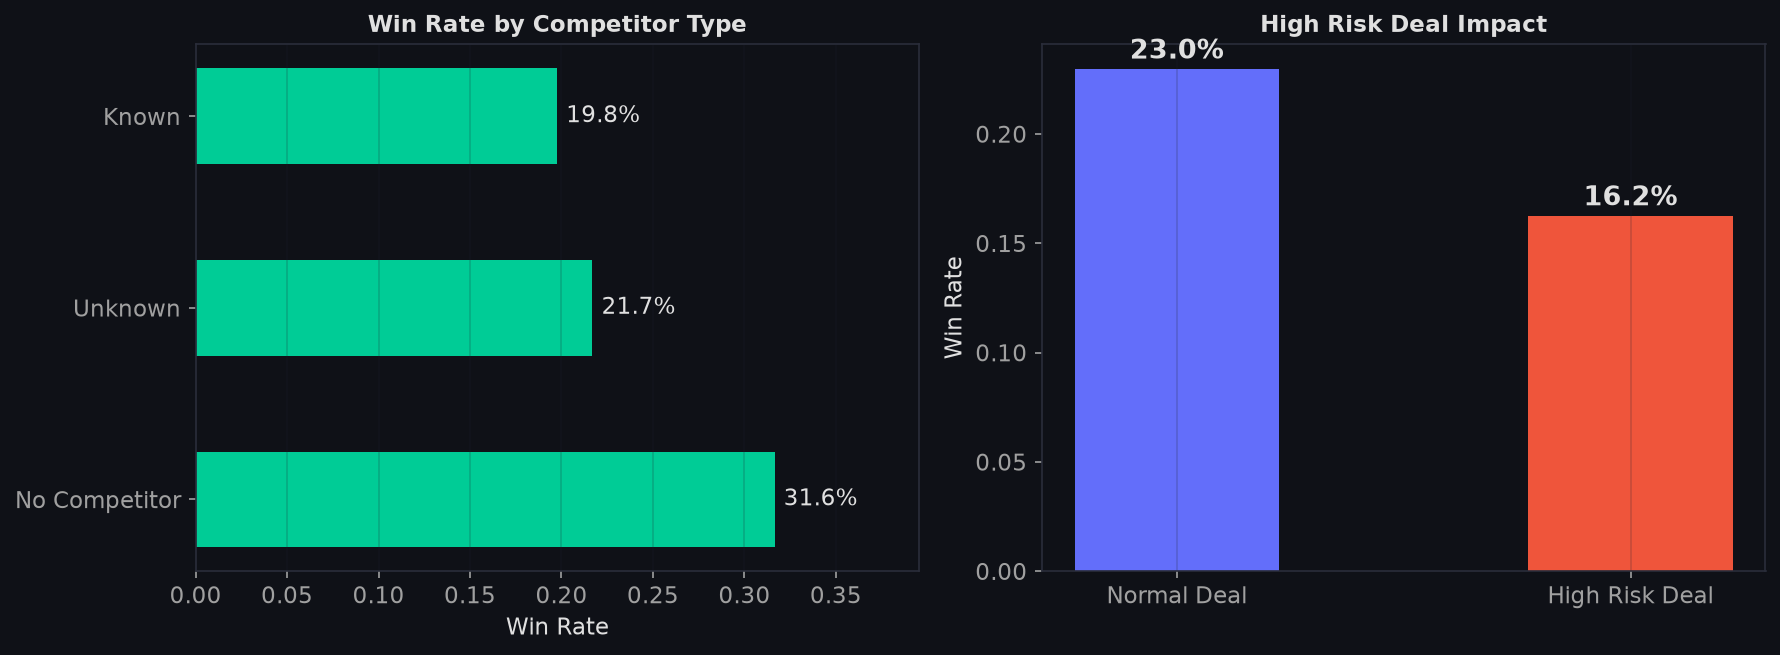

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

# ── Dark theme styling ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#0f1117",
    "axes.edgecolor": "#2a2d3a", "axes.labelcolor": "#e0e0e0",
    "text.color": "#e0e0e0", "xtick.color": "#a0a0a0", "ytick.color": "#a0a0a0",
    "grid.color": "#1e2130", "figure.dpi": 150, "font.family": "sans-serif", "font.size": 11,
})
PALETTE = ["#636efa", "#ef553b", "#00cc96", "#ffa15a", "#ab63fa", "#19d3f3"]

val_auc = roc_auc_score(y_val, y_val_prob)

# ── VISUAL 1: AUC improvement (old baseline vs new model) ─────────────────
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["Original\n(no Amount)", "Improved\n(+ Amount)"], [0.8601, val_auc],
              color=[PALETTE[4], PALETTE[2]], width=0.5)
for bar, val in zip(bars, [0.8601, val_auc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}",
            ha="center", fontweight="bold", fontsize=14)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel("AUC")
ax.set_title("Model Improvement — Adding Deal Amount", fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("v1_auc_improvement.png", bbox_inches="tight")
plt.show()

# ── VISUAL 2: Confusion matrix at tuned threshold ──────────────────────────
y_val_pred = (y_val_prob >= best_threshold).astype(int)
cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False,
            xticklabels=["Pred Loss", "Pred Win"], yticklabels=["Actual Loss", "Actual Win"],
            annot_kws={"fontsize": 16, "fontweight": "bold"}, linewidths=0.5, linecolor="#2a2d3a", ax=ax)
ax.set_title(f"Confusion Matrix (threshold={best_threshold:.2f})", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("v2_confusion_matrix.png", bbox_inches="tight")
plt.show()

# ── VISUAL 3: ROC curve ─────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color=PALETTE[0], linewidth=2.5, label=f"Model (AUC = {val_auc:.3f})")
ax.plot([0,1],[0,1], color="#555", linestyle="--", linewidth=1, label="Random guess")
ax.fill_between(fpr, tpr, alpha=0.08, color=PALETTE[0])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve", fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="lower right", framealpha=0.3); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("v3_roc_curve.png", bbox_inches="tight")
plt.show()

# ── VISUAL 4: Precision-recall curve, chosen threshold marked ─────────────
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(recalls, precisions, color=PALETTE[2], linewidth=2.5)
ax.fill_between(recalls, precisions, alpha=0.08, color=PALETTE[2])
ax.scatter([recalls[best_idx]], [precisions[best_idx]], color=PALETTE[1], s=100, zorder=5,
           label=f"Chosen threshold ({best_threshold:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve", fontsize=13, fontweight="bold", pad=12)
ax.legend(framealpha=0.3); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("v4_precision_recall.png", bbox_inches="tight")
plt.show()

# ── VISUAL 5: Feature importance ───────────────────────────────────────────
importance = pd.Series(final_model.feature_importance(importance_type="gain"),
                        index=final_model.feature_name()).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = [PALETTE[1] if v >= importance.quantile(0.75) else PALETTE[4] for v in importance.values]
ax.barh(importance.index, importance.values, color=colors, height=0.6)
ax.set_xlabel("Importance (gain)")
ax.set_title("What Drives Win Probability", fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig("v5_feature_importance.png", bbox_inches="tight")
plt.show()

# ── VISUAL 6: Probability distribution ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(y_val_prob[y_val==0], bins=50, alpha=0.6, color=PALETTE[1], label="Actual Losses", density=True)
ax.hist(y_val_prob[y_val==1], bins=50, alpha=0.6, color=PALETTE[0], label="Actual Wins", density=True)
ax.axvline(best_threshold, color="#e0e0e0", linestyle="--", linewidth=1.5, label=f"Chosen threshold ({best_threshold:.2f})")
ax.set_xlabel("Predicted Win Probability"); ax.set_ylabel("Density")
ax.set_title("Model Separates Wins From Losses", fontsize=13, fontweight="bold", pad=12)
ax.legend(framealpha=0.3); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("v6_probability_distribution.png", bbox_inches="tight")
plt.show()

# ── VISUAL 7: Win rate by business segment (raw data, good for storytelling) ─
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
wr = df.groupby("Competitor Type")[TARGET_COL].mean().sort_values(ascending=False)
axes[0].barh(wr.index, wr.values, color=PALETTE[2], height=0.5)
for i, v in enumerate(wr.values):
    axes[0].text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=11)
axes[0].set_xlabel("Win Rate"); axes[0].set_title("Win Rate by Competitor Type", fontsize=11, fontweight="bold")
axes[0].set_xlim(0, wr.max()*1.25)

wr2 = df.groupby("High Risk Deal")[TARGET_COL].mean()
axes[1].bar(["Normal Deal", "High Risk Deal"], wr2.values, color=[PALETTE[0], PALETTE[1]], width=0.45)
for i, v in enumerate(wr2.values):
    axes[1].text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Win Rate"); axes[1].set_title("High Risk Deal Impact", fontsize=11, fontweight="bold")

for ax in axes: ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig("v7_win_rate_segments.png", bbox_inches="tight")
plt.show()

# **CSV OF PREDICTIONS ON DATA**

In [9]:
import joblib
#final_model = joblib.load("model_config.pkl")  
#best_threshold = 0.597

final_model = joblib.load("win_probability_model_final.pkl")
config = joblib.load("model_config.pkl")
best_threshold = config["best_threshold"]
FEATURES = config["features"]

In [15]:
import pandas as pd
import joblib

# Reload fresh from source to guarantee every original column is present
# (safer than reusing df if you've been experimenting with feature drops/additions)
DATA_PATH = "train_data 2.csv"  # <- your actual path
df_export = pd.read_csv(DATA_PATH)

CATEGORICAL_COLS = ["Route To Market", "Supplies Subgroup", "Competitor Type"]
NUMERIC_COLS = [
    "Elapsed Days In Sales Stage", "Sales Stage Change Count",
    "Client Size By Revenue", "Revenue From Client Past Two Years",
    "Is Stalled", "Bounced A Lot", "Is Existing Client",
    "High Risk Deal", "Stage Bounce Rate", "Opportunity Amount USD",
]
FEATURES = CATEGORICAL_COLS + NUMERIC_COLS

for col in CATEGORICAL_COLS:
    df_export[col] = df_export[col].astype("category")

# ── Score every deal with the trained model ────────────────────────────────
df_export["predicted_win_probability"] = final_model.predict(
    df_export[FEATURES], num_iteration=final_model.best_iteration
)

df_export["predicted_label"] = (
    df_export["predicted_win_probability"] >= best_threshold
).map({True: "Predicted Win", False: "Predicted Loss"})

df_export["expected_revenue"] = (
    df_export["predicted_win_probability"] * df_export["Opportunity Amount USD"]
)


# ── Simple rule-based recommendation, for the dashboard's action column ────
def get_recommendation(row):
    if row["High Risk Deal"] == 1:
        return "High value deal stalled — escalate to manager, schedule exec call within 48 hours"
    elif row["Is Stalled"] == 1 and row["Bounced A Lot"] == 1:
        return "Stalled and unstable — likely internal disagreement, recommend re-scoping session"
    elif row["Is Stalled"] == 1:
        return "Deal stalled — follow up with client within 5 days"
    elif row["Bounced A Lot"] == 1:
        return "Deal has bounced between stages repeatedly — clarify decision-maker alignment"
    elif row["predicted_win_probability"] >= 0.75:
        return "High likelihood of closing — prioritize resources here"
    else:
        return "On track — continue standard follow-up cadence"

df_export["recommendation"] = df_export.apply(get_recommendation, axis=1)


# ── Export ──────────────────────────────────────────────────────────────────
output_cols = [
    "Opportunity Number", "Opportunity Result", "Opportunity Amount USD",
    "Route To Market", "Supplies Subgroup", "Competitor Type",
    "Elapsed Days In Sales Stage", "Sales Stage Change Count",
    "Client Size By Revenue", "Revenue From Client Past Two Years",
    "Is Stalled", "Bounced A Lot", "Is Existing Client", "High Risk Deal",
    "Stage Bounce Rate", "predicted_win_probability", "predicted_label",
    "expected_revenue", "recommendation",
]

df_export[output_cols].to_csv("deals_scored_for_dashboard.csv", index=False)
print(f"Exported {len(df_export)} scored deals to deals_scored_for_dashboard.csv")
print(df_export[output_cols].head())

Exported 62376 scored deals to deals_scored_for_dashboard.csv
   Opportunity Number  Opportunity Result  Opportunity Amount USD  \
0             9489573                   0                  300000   
1             7910456                   0                   33400   
2             7791278                   0                   20000   
3             6518541                   0                     600   
4             7713087                   1                   80000   

  Route To Market  Supplies Subgroup Competitor Type  \
0    Fields Sales   Motorcycle Parts         Unknown   
1        Reseller  Replacement Parts           Known   
2        Reseller   Motorcycle Parts         Unknown   
3        Reseller  Garage & Car Care         Unknown   
4        Reseller      Shelters & RV         Unknown   

   Elapsed Days In Sales Stage  Sales Stage Change Count  \
0                            4                         3   
1                           47                         5   
2     

In [16]:
import pandas as pd
import joblib

# Reload fresh from source to guarantee every original column is present
# (safer than reusing df if you've been experimenting with feature drops/additions)
DATA_PATH = "test_data 2.csv"  # <- your actual path
df_export = pd.read_csv(DATA_PATH)

CATEGORICAL_COLS = ["Route To Market", "Supplies Subgroup", "Competitor Type"]
NUMERIC_COLS = [
    "Elapsed Days In Sales Stage", "Sales Stage Change Count",
    "Client Size By Revenue", "Revenue From Client Past Two Years",
    "Is Stalled", "Bounced A Lot", "Is Existing Client",
    "High Risk Deal", "Stage Bounce Rate", "Opportunity Amount USD",
]
FEATURES = CATEGORICAL_COLS + NUMERIC_COLS

for col in CATEGORICAL_COLS:
    df_export[col] = df_export[col].astype("category")

# ── Score every deal with the trained model ────────────────────────────────
df_export["predicted_win_probability"] = final_model.predict(
    df_export[FEATURES], num_iteration=final_model.best_iteration
)

df_export["predicted_label"] = (
    df_export["predicted_win_probability"] >= best_threshold
).map({True: "Predicted Win", False: "Predicted Loss"})

df_export["expected_revenue"] = (
    df_export["predicted_win_probability"] * df_export["Opportunity Amount USD"]
)


# ── Simple rule-based recommendation, for the dashboard's action column ────
def get_recommendation(row):
    if row["High Risk Deal"] == 1:
        return "High value deal stalled — escalate to manager, schedule exec call within 48 hours"
    elif row["Is Stalled"] == 1 and row["Bounced A Lot"] == 1:
        return "Stalled and unstable — likely internal disagreement, recommend re-scoping session"
    elif row["Is Stalled"] == 1:
        return "Deal stalled — follow up with client within 5 days"
    elif row["Bounced A Lot"] == 1:
        return "Deal has bounced between stages repeatedly — clarify decision-maker alignment"
    elif row["predicted_win_probability"] >= 0.75:
        return "High likelihood of closing — prioritize resources here"
    else:
        return "On track — continue standard follow-up cadence"

df_export["recommendation"] = df_export.apply(get_recommendation, axis=1)


# ── Export ──────────────────────────────────────────────────────────────────
output_cols = [
    "Opportunity Number", "Opportunity Result", "Opportunity Amount USD",
    "Route To Market", "Supplies Subgroup", "Competitor Type",
    "Elapsed Days In Sales Stage", "Sales Stage Change Count",
    "Client Size By Revenue", "Revenue From Client Past Two Years",
    "Is Stalled", "Bounced A Lot", "Is Existing Client", "High Risk Deal",
    "Stage Bounce Rate", "predicted_win_probability", "predicted_label",
    "expected_revenue", "recommendation",
]

df_export[output_cols].to_csv("deals_scored_for_dashboard_test.csv", index=False)
print(f"Exported {len(df_export)} scored deals to deals_scored_for_dashboard_test.csv")
print(df_export[output_cols].head())

Exported 15594 scored deals to deals_scored_for_dashboard_test.csv
   Opportunity Number  Opportunity Result  Opportunity Amount USD  \
0             7050675                   0                   39473   
1             6759226                   0                  145000   
2             5958427                   1                   25000   
3             7016414                   0                  306748   
4             7003614                   0                  150000   

  Route To Market     Supplies Subgroup Competitor Type  \
0        Reseller      Motorcycle Parts         Unknown   
1           Other  Exterior Accessories         Unknown   
2    Fields Sales  Exterior Accessories         Unknown   
3           Other      Motorcycle Parts         Unknown   
4    Fields Sales     Replacement Parts         Unknown   

   Elapsed Days In Sales Stage  Sales Stage Change Count  \
0                           73                         2   
1                           70             